***Linear Regression Model***  
basically it is a regression model but it assumes a linear relationship between variables.

***Basic Terminology***

---

Training set : the data used to train the model.

x : "input" variable or *feature*

y : "output" variable or the *target* variable

(x,y) : a single training example

**The workflow:**

---
 We feed our data (features and targets), the training set into the learning algorithm which gives us a *function* or a *model* .

 Then we use this model by feeding it the input x and it will give us the predicted output y' (estimated y).

 The graph we just plotted above is an example of the liner regression model.

 A Simple Linear Reagression uses the formula/model:

    f(x)= y' = mx+c

    where m= slope or weight
    and c is the y-intercept
We can call this Linear Regression with one variable.



***Cost Function:***

---
Basically the cost function is *Squared error Cost Function*.

Mathematically:

    J(w,b) = 1/2m ∑(y' - y)^2

    where w is the slope,
    b is the intercept,
    m is the number of training examples,
    ∑ is summation from i=1 to m,
    and (y'-y) is the error.
    y' is the predicted value
    and y is the actual correct output.

and since y' = f(x),

    J(w,b) = 1/2m ∑(f(x) - y)^2

**Cost Function Intuition:**

---
lets say our model is

    f(x) = wx + b

and our parameters are
    w (slope) and b(intercept)

Cost functions is:

    J(w,b) = 1/2m ∑(y' - y)^2

So our goal is to minimise the Cost Function J(w,b) (meaning we have to minimise the errors) .

Lets first study the simplified version of our model i.e.,

    f(x)= wx

    meaning we just put b = 0

Therefore the cost function will also depend only on a single parameter which is w so,

    J(w) = 1/2m ∑(f(x) - y)^2

    where f(x) is a function of x with w fixed.


Now the calculative part:

    for w = 1,
          f(x) = y' = x
          so for x=1,2,3,.....
          y' will also be = 1,2,3,... respectively.

        and the cost function in each case will result in zero.

        Lets try to visualise that:









In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
x_train= np.array([1.0,2.0,3.0])
y_train= np.array([1.0,2.0,3.0])
def compute_model_output(x,w):
  m=x.shape[0]
  f_wb=np.zeros(m)
  for i in range(m):
    f_wb[i]= w*x[i]
  return f_wb




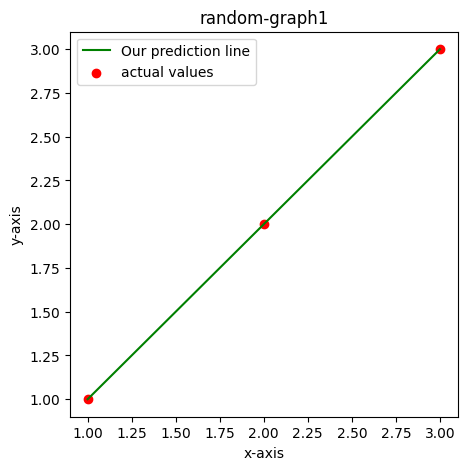

In [ ]:
temp_f_wb=compute_model_output(x_train,1)

#plotting
plt.figure(figsize=(5,5))     # this will give us the canvas to design the graph on
plt.plot(x_train,temp_f_wb,c="g",label="Our prediction line") # this will give us the straight predicted line
plt.scatter(x_train,y_train,marker="o",c="r",label="actual values")     #this will give us the actual values
plt.title("random-graph1")
plt.xlabel("x-axis")
plt.ylabel("y-axis")
plt.legend()
plt.show()

now lets see for w=0.5

    for w=0.5
    f(x) = y' = 0.5*x
    so the predicted outcome for x=1,2,3,.... will be 0.5,1,1.5,.... and so on.
    
    therefore the cost function will be J(w)= 0.58 approximately.

 lets see the graph for this as well.
   

In [ ]:
x_train= np.array([1.0,2.0,3.0])
y_train= np.array([1.0,2.0,3.0])
def compute_model_output(x,w):
  m=x.shape[0]
  f_wb=np.zeros(m)
  for i in range(m):
    f_wb[i]= w*x[i]
  return f_wb


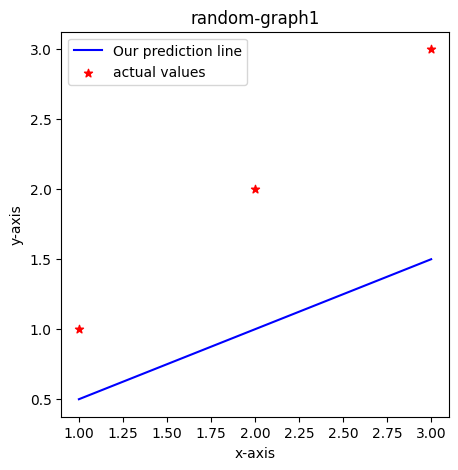

In [ ]:
temp_f_wb=compute_model_output(x_train,0.5)

#plotting
plt.figure(figsize=(5,5))
plt.plot(x_train,temp_f_wb,c="b",label="Our prediction line")
plt.scatter(x_train,y_train,marker="*",c="r",label="actual values")
plt.title("random-graph1")
plt.xlabel("x-axis")
plt.ylabel("y-axis")
plt.legend()
plt.show()

soo similarly we will keep plotting graphs for other different values of w and find the value of each of the cost function lets try to visualise that as well.

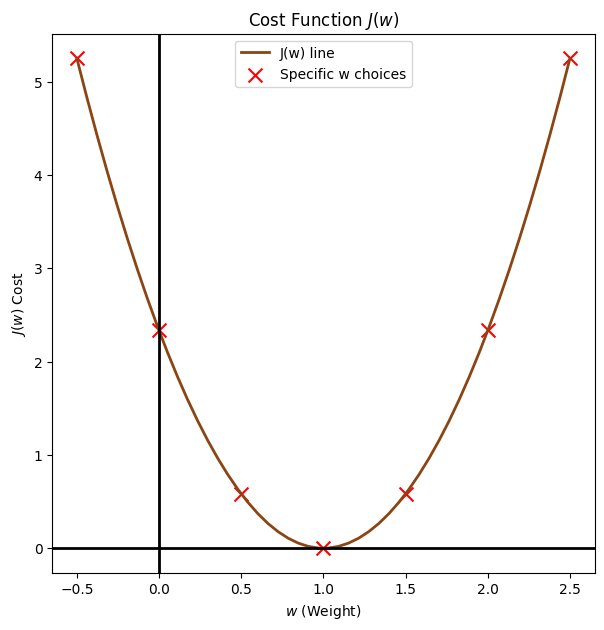

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

x_train=np.array([1.0,2.0,3.0])
y_train=np.array([1.0,2.0,3.0])

def compute_cost(x,y,w):
  m=x.shape[0]
  cost=0
  for i in range(m):
    f_wb=w*x[i]
    error=(f_wb-y[i])**2
    cost+=error
  total_cost=1/(2*m)*cost
  return total_cost

#but we want to draw a smooth line for that we need multiple points for our program to connect to and make a smooth line for that
w_values = np.linspace(-0.5,2.5,50)
J_values = np.zeros(len(w_values))

for i in range(len(w_values)):
  J_values[i]=compute_cost(x_train,y_train,w_values[i])

# "plotting"
plt.figure(figsize=(7,7))
plt.plot(w_values,J_values,c="saddlebrown", linewidth=2,label="J(w) line")

w_marks=np.array([-0.5, 0.0, 0.5, 1.0, 1.5, 2.0, 2.5])
J_marks=[compute_cost(x_train,y_train,w) for w in w_marks]
plt.scatter(w_marks,J_marks,marker='x',c='r',s=100,label="Specific w choices")

plt.title("Cost Function $J(w)$")
plt.xlabel("$w$ (Weight)")
plt.ylabel("$J(w)$ Cost")
plt.axhline(0,color="black",linewidth=2)
plt.axvline(0,color="black",linewidth=2)
plt.legend()
plt.show()








**Visualisation of the cost function curve in 3D**

---
The cost function basically looks like a soup bowl or a hammock in 3D.
The goal is to move to the absolute lowest geographical point of that 3D bowl. That lowest point is called the global minimum.
At this point the value of the Cost function(error) will be minimum.

**The concept of elliptical rings (*what i call them- the onion rings*)**
---
This is basically a graph between the parameters of the cost function J which are- b and w
and this graph's line are in the form of elliptical rings.

Each ring represents a level of the 3D Soup Bowl (the 3D cost function) and every point on that ring has the same value of the Cost function.


In [ ]:
import numpy as np
import plotly.graph_objects as go

# --- STEP 1: The Math (Generating the Data) ---
# Create an array of values for weights (w) and biases (b)
w = np.linspace(-100, 100, 50)
b = np.linspace(-100, 100, 50)

# Create a 2D grid from these 1D arrays (this creates the 'floor' of the 3D space)
W, B = np.meshgrid(w, b)

# Define a simple convex Cost Function: J(w,b) = w^2 + b^2
# This perfectly mimics the "bowl" shape.
Cost = W**2 + B**2

# --- STEP 2: The Trace (Defining the Visual) ---
# We tell Plotly to map our W, B, and Cost variables to the X, Y, and Z axes of a 3D surface.
surface_trace = go.Surface(
    x=W,
    y=B,
    z=Cost,
    colorscale='Viridis', # A standard color map used in Data Science
    colorbar=dict(title='Cost J(w,b)')
)

# --- STEP 3: The Layout (The Canvas) ---
layout = go.Layout(
    title='Interactive 3D Cost Function Surface',
    autosize=False,
    width=800,
    height=800,
    scene=dict(
        xaxis_title='Weight (w)',
        yaxis_title='Bias (b)',
        zaxis_title='Cost J(w,b)'
    )
)

# --- STEP 4: Render ---
# Combine the trace and layout into a Figure object and display it
fig = go.Figure(data=[surface_trace], layout=layout)


# Because Plotly renders via the browser, this will open a new tab with your interactive plot.
# If you are in a Jupyter Notebook, it will render directly below the cell.
fig.show()

This is what the soup bowl 3D graph looks like (keep in mind that this is not the actual cost function but just a visualisation of what a soup bowl looks like).

Now lets take a look at what the actual cost function graph will look like.

In [ ]:
import numpy as np
import plotly.graph_objects as go

# here X is the price of the house in 1000s of sq ft and Y is the price of the house in $1000s

X=np.array([1,2,3])
Y=np.array([300,500,800])
m=len(X)

#now lets make the mesh (the wide net)
w=np.linspace(-100,400,50)
b=np.linspace(-200,200,50)
W , B = np.meshgrid(w,b)

# the mathematical part
Cost= np.zeros(W.shape)

for i in range(m):
  prediction= W*X[i]+B
  error= prediction - Y[i]
  Cost+= (error**2)

Cost=  Cost/2*m

# now the rendering architecture

surface_trace= go.Surface(
    x=W,
    y=B,
    z=Cost,
    colorscale="Viridis",
    colorbar=dict(title='Cost function J(w,b)')
)

layout=go.Layout(
    title="Acutal mean squared error cost Surface",
    autosize=False,
    width=800,
    height=800,
    scene=dict(
        xaxis_title="weight(w)",
        yaxis_title="bias or intercept(b)",
        zaxis_title="cost function Z(w,b)"

    )
)
fig=go.Figure(data=[surface_trace],layout = layout)
fig.show()


This is what the visualisation of the acutal MSE cost function J(w,b) looks like.

# Gradient Descent
---

To find the values of w and b that result in the least possible value of the cost function J(w,b) (basically to minimise the const function) we use an algorithm called **Gradient Descent**

***Gradient Descent*** doesn't just work for linear regression but works fo any general function.


Here is how it works:

Lets say we have some function J(w,b) and we want to find  min J(w,b).

*So* start with some values of w,b. Then it goes in the direction oF steepest descent which just means that it takes a tiny little step to go to the least value of the cost function J in a direction such that you will reach min J(w,b) faster as compared to any other direction it can take a step in.

And then it takes another step and another step and so onn unit you find yourself at a local minimum.

**Interesting property:**
If you had chosen different starting values of parameters w and b and the cost function graph had multiple local minimas then you could have ended up in a totally different local minima of the cost function graph.

# Implimenting the Gradient Descent Algorithm and intuition:

---

On each step the parameter w is updated mathematically as:

$w = w - \alpha \frac{\partial}{\partial w} J(w, b)$

   where α is the "learning rate".

   and $\frac{\partial}{\partial w} J(w, b)$ is the derivative of the cost function J(w,b) wrt w.


And similarly the parameter b is also updated mathematically as:

$b = b - \alpha \frac{\partial}{\partial b } J(w,b)$  


***Learning rate:***
It usually is a very small value. Basically the learning rate α controls how big of a step you take when you move downhill.
      
**NOTE:**

      If α is really large then you are taking huge steps down hill which may result in moving further away from the local minimum and possibly never reaching the local minimum as it passes it each time.

      if α is too small it will take a large number of baby steps to reach the local minimum. It will be quite annoying and slow but will eventually reach the local minimum.

*DERIVATIVE OF THE COST FUNCTION*   $\frac{\partial}{\partial w} J(w, b)$ :

This is basically the tangent to the cost function curve or in simpler words it is the slope of the function J(w,b) at a specific point.

**NOTE:**
if the tangent line is  that we draw along the  right side of a 2d curve is pointing upwards then the slope is +ve and so derivative term is +ve.

    this means that the w will be updated as :
    w = w - α * (positive number)
    
    this means that the value of w will decrease which is correct since now we are moving towards the minimum value of the Cost J.
Similarly if we draw the tangent line on the left side of the 2d curve we notice that it is pointing downwards so the slope is -ve and hence the derivative term is also -ve.
    
    this means that the w will be updated as :
    w = w - α * (negative number)
    
    this means that the value of w will increase which is correct since now we are moving towards the minimum value of the Cost J.



And we have to repeat these steps for both parameters w and b until the album converges and convergence means that we reach the point at local minimum where parameters w and b no longer change much each step you take.

**NOTE:**

We have to update both parameters w and b simutaneously (at the same time)

We can update them correctly and simutaneously like this:

$temp-w = w - \alpha \frac{\partial}{\partial w} J(w, b)$

$temp-b = b - \alpha \frac{\partial}{\partial b} J(w, b)$

w = temp-w

b = temp-b

REMEMBER:
 in the first formula to calculate the temp-w we use the pre-updated value of w. *Similarly*, in the temp-b formula we use the same pre-updated value of w in J(w,b) as well.



***Case of local minimum:***

Lets say we have a Cost function which has two local minimum and we have already reached one minimum then the tangent to the curve at that point will be a straight line and the slope will be *zero* hence the derivative term will be zero.

This just means that :
       w wwala
      
                